#Primary Market random walk test - Platinum (PL)


## 0. Market intro

In this notebook, PL is the primary market used for this project.

In the project market table, PL is listed as the ticker for Platinum futures. The data file used here is PL-5minHLV.csv, so I treat PL as the platinum futures series in this notebook.

The PL price series does not look stable over the full sample. It has several different periods. Around 2008, price moved up fast and then dropped sharply. Around 2010 to 2012, there was another strong upward period. From around 2013 to 2016, price moved down. From 2016 to 2024, the market was more sideways and range-bound. In 2025 to 2026, price increased again and volatility also became higher.

So PL is not just one simple stable market. It has trend periods, reversal periods, and long quiet periods. This makes PL useful for Random Walk analysis, because the inefficiency may change by time horizon.

Because the full sample includes both crisis-like moves and quieter periods, the return behavior is unlikely to have constant volatility.

## 1. Setup

In [274]:
import math
import os
import re
from typing import Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

In [275]:
MARKET_NAME = "PL"
MARKET_LABEL = "platinum futures"
CSV_FILENAME = "PL-5minHLV.csv"

MINUTES_PER_BAR = 5
VARIANCE_RATIO_HORIZONS = [2, 4, 8, 16, 32, 64, 128]
PUSH_RESPONSE_H_VALUES = [2, 4, 8, 16, 32]
PUSH_RESPONSE_EMPIRICAL_N_BINS = 9

BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, CSV_FILENAME)

OUTPUT_DIR = os.path.join(BASE_DIR, "random_walk_outputs")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

In [276]:
# Generate file slug
def file_slug(name):
    s = re.sub('[^a-zA-Z0-9]+', '_', str(name).strip()).strip('_').lower()
    return s or 'market'

FILE_SLUG = file_slug(MARKET_NAME)

## 2. Helper functions

In [277]:
# Normal CDF
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

In [278]:
# Two-sided p-value from z
def z_pvalue(z):
    if np.isnan(z):
        return float('nan')
    return float(2.0 * (1.0 - norm_cdf(abs(z))))

In [279]:
# Welch t mean difference
def welch_t(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return float('nan')
    mx, my = (float(np.mean(x)), float(np.mean(y)))
    vx, vy = (float(np.var(x, ddof=1)), float(np.var(y, ddof=1)))
    se = math.sqrt(vx / len(x) + vy / len(y))
    if se == 0 or math.isnan(se):
        return float('nan')
    return float((mx - my) / se)

## 3. Load data

####Data range

Instrument: PL platinum futures

Exchange: NYMEX-CME

Native scale: 5min OHLCV bars

Raw file: PL-5minHLV.csv

Cleaned price sample: 2007-10-02 08:25:00 to 2026-04-10 13:05:00

Return sample after gap filtering: 2007-10-02 08:30:00 to 2026-04-10 13:05:00

Main scale: 5min

Longer time scales are built from the cleaned 5min price data.

In [280]:
def load_data():
    df_raw = pd.read_csv(CSV_PATH)

    df = pd.DataFrame()
    df["datetime"] = pd.to_datetime(
        df_raw["Date"].astype(str) + " " + df_raw["Time"].astype(str),
        errors="coerce"
    )
    df["Close"] = pd.to_numeric(df_raw["Close"], errors="coerce")

    if "Volume" in df_raw.columns:
        df["Volume"] = pd.to_numeric(df_raw["Volume"], errors="coerce")

    df = df.dropna(subset=["datetime", "Close"])
    df = df.sort_values("datetime").reset_index(drop=True)

    dup_count = int(df["datetime"].duplicated().sum())
    df = df.drop_duplicates(subset=["datetime"], keep="first").reset_index(drop=True)

    non_positive_count = int((df["Close"] <= 0).sum())
    df = df[df["Close"] > 0].reset_index(drop=True)

    df.attrs["dup_count"] = dup_count
    df.attrs["non_positive_count"] = non_positive_count

    return df

In [281]:
df_prices = load_data()
n_before_returns = len(df_prices)

## 4. Clean data and compute returns

## Data conventions

We use the Close price from PL-5minHLV.csv.

Returns are log returns:$r_t = \ln(P_t / P_{t-1})$

Before computing returns, the data is sorted by timestamp.

When returns are created, we only keep observations where the time gap is exactly 5 minutes, which removes overnight gaps, weekend gaps, holiday gaps, and other non-5-minute gaps.

We do not fill any missing prices.

This is important because the Random Walk test should focus on consecutive intraday 5-minute returns, not returns that include a long time gap.So the result should be interpreted as intraday consecutive-bar result, not full close-to-close result.

In [282]:
# We only keep the time gap exactly equals 5 minutes,
# which will delete any overnight/weekend/holiday gap return,
# and there's no imputation or forward/backward fill
def calc_returns(df, minutes_per_bar=5):
    out = df.copy().sort_values('datetime').reset_index(drop=True)
    out['time_gap'] = out['datetime'].diff()
    out['raw_log_ret'] = np.log(out['Close']).diff()
    expected_gap = pd.Timedelta(minutes=minutes_per_bar)
    valid_gap = out['time_gap'] == expected_gap
    out['log_ret'] = out['raw_log_ret'].where(valid_gap)
    n_raw_returns = int(out['raw_log_ret'].notna().sum())
    n_valid_returns = int(out['log_ret'].notna().sum())
    n_gap_returns_removed = int(n_raw_returns - n_valid_returns)
    out.attrs['n_raw_returns'] = n_raw_returns
    out.attrs['n_valid_returns'] = n_valid_returns
    out.attrs['n_gap_returns_removed'] = n_gap_returns_removed
    out.attrs['expected_gap_minutes'] = minutes_per_bar
    out = out.dropna(subset=['log_ret']).reset_index(drop=True)
    return out

In [283]:
# Compute the log return
df = calc_returns(df_prices, MINUTES_PER_BAR)
n_after_returns = len(df)

n_raw_returns = int(df.attrs.get("n_raw_returns", n_before_returns - 1))
n_valid_returns = int(df.attrs.get("n_valid_returns", n_after_returns))
n_gap_returns_removed = int(df.attrs.get("n_gap_returns_removed", n_raw_returns - n_valid_returns))

In [284]:
print(f"Cleaned price rows: {n_before_returns:,}")
print(f"Valid consecutive {MINUTES_PER_BAR}-minute returns kept: {n_valid_returns:,}")
print(f"Non-{MINUTES_PER_BAR}-minute gap returns removed: {n_gap_returns_removed:,}")
print(f"Sample period: {df['datetime'].min()} to {df['datetime'].max()}")

Cleaned price rows: 272,343
Valid consecutive 5-minute returns kept: 267,564
Non-5-minute gap returns removed: 4,778
Sample period: 2007-10-02 08:30:00 to 2026-04-10 13:05:00


In [285]:
# Preprocessing diagnostics table
raw_rows = len(pd.read_csv(CSV_PATH))

preprocess_diag = pd.DataFrame(
    {
        "item": [
            "raw rows in csv",
            "cleaned price rows",
            "duplicate timestamps removed",
            "non-positive close rows removed",
            "raw adjacent returns",
            "valid consecutive 5-minute returns kept",
            "non-5-minute gap returns removed",
            "start timestamp used in returns",
            "end timestamp used in returns",
            "price filling / imputation",
            "return interpretation",
        ],
        "value": [
            raw_rows,
            len(df_prices),
            int(df_prices.attrs.get("dup_count", 0)),
            int(df_prices.attrs.get("non_positive_count", 0)),
            int(df.attrs.get("n_raw_returns", len(df_prices) - 1)),
            int(df.attrs.get("n_valid_returns", len(df))),
            int(df.attrs.get("n_gap_returns_removed", 0)),
            df["datetime"].min(),
            df["datetime"].max(),
            "none",
            "consecutive intraday 5-minute bars only",
        ],
    }
)


display(preprocess_diag)

,item,value
0,raw rows in csv,272343
1,cleaned price rows,272343
2,duplicate timestamps removed,0
3,non-positive close rows removed,0
4,raw adjacent returns,272342
5,valid consecutive 5-minute returns kept,267564
6,non-5-minute gap returns removed,4778
7,start timestamp used in returns,2007-10-02 08:30:00
8,end timestamp used in returns,2026-04-10 13:05:00
9,price filling / imputation,none


#### Result

The cleaned price sample has 272,343 observations before returns.

After keeping only consecutive 5-minute bars, we have 267,564 valid log returns.

There are 4,778 non-5-minute gap returns removed.

No price filling is used.

So the return data is only based on consecutive intraday 5-minute bars. It is not full close-to-close return with overnight or weekend gaps.

## 5. Summary statistics

In [286]:
# Background summary
stats_tbl = (
    df[["Close", "log_ret"]]
    .describe()
    .T.loc[:, ["count", "mean", "std", "min", "max"]]
    .round(6)
)

display(stats_tbl)

,count,mean,std,min,max
Close,267564.0,1211.357844,345.205697,586.700000,2877.000000
log_ret,267564.0,-0.000001,0.001546,-0.043902,0.032761


## 6. Overall market

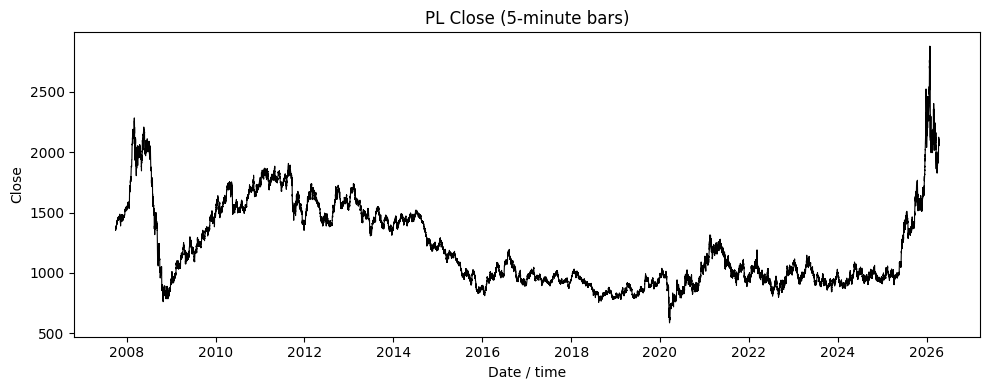

In [287]:
# Close price plot
fig1, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df["datetime"], df["Close"], linewidth=0.8, color="black")
ax1.set_title(f"{MARKET_NAME} Close (5-minute bars)")
ax1.set_xlabel("Date / time")
ax1.set_ylabel("Close")

fig1.tight_layout()

close_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_close.png")
fig1.savefig(close_path, dpi=120, bbox_inches="tight")

### Result

The PL price level changes a lot over the sample.

The return series is mostly centered around zero, but volatility is not constant.

There are clear large volatility periods around 2008, 2020, and 2025-2026. So returns are not homoskedastic. Because of this, the robust VR standard error, robust p-value, and robust confidence interval are more useful than only looking at the raw VR number.

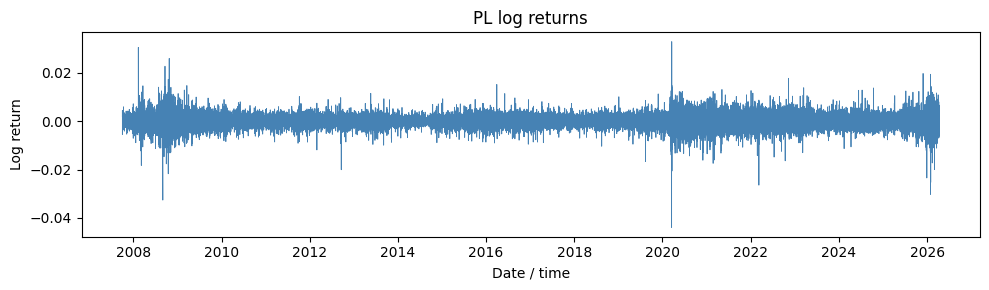

In [288]:
# Log return plot
fig2, ax2 = plt.subplots(figsize=(10, 3))

ax2.plot(df["datetime"], df["log_ret"], linewidth=0.6, color="steelblue")
ax2.set_title(f"{MARKET_NAME} log returns")
ax2.set_xlabel("Date / time")
ax2.set_ylabel("Log return")

fig2.tight_layout()

logret_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_log_returns.png")
fig2.savefig(logret_path, dpi=120, bbox_inches="tight")

## Result

The close price plot shows PL has several different price regimes.

The log-return plot shows volatility clustering.Most returns are close to zero, but some large return spikes happen in clusters, meaning the variance of returns is changing over time. This indicates the importance of looking into the robust version for the VR test.

## 7. Variance Ratio test


The VR test asks if returns look like a random walk.

If they do, the variance of a q-period return should be about q times the 1-period variance.

So:
- VR(q) = 1 means random walk
- VR(q) > 1 means momentum
- VR(q) < 1 means mean reversion

We focus on the robust version because volatility changes over time.

In [289]:
# Core Variance Ratio (VR) calculation
# The VR tests whether the variance of q-period returns is q times the variance of 1-period returns.
# Under a pure Random Walk, VR(q) should equal 1.0.
# VR > 1 implies momentum (positive autocorrelation), VR < 1 implies mean-reversion (negative autocorrelation).
def vr(log_returns, q, demean=True):
    if q < 2:
        raise ValueError('q must be >= 2')
    r = log_returns.dropna().astype(float)
    if len(r) < q + 10:
        return float('nan')

    # rq is the rolling sum of q single-period log returns (equivalent to the overlapping q-period log return)
    rq = r.rolling(window=q).sum().dropna()
    rq = rq if not demean else rq - rq.mean()
    r0 = r if not demean else r - r.mean()

    # Calculate unbiased sample variances (ddof=1)
    var_rq = rq.var(ddof=1)
    var_r = r0.var(ddof=1)

    if var_r == 0 or np.isnan(var_r):
        return float('nan')

    # The variance ratio: (Var of q-period returns) / (q * Var of 1-period returns)
    return float(var_rq / (q * var_r))

In [290]:
# Robust VR test
def vr_test(log_returns, q):
    if q < 2:
        return {'q': q, 'VR': float('nan'), 'robust_z': float('nan'), 'robust_p_value': float('nan'), 'robust_standard_error': float('nan'), 'ci_lower': float('nan'), 'ci_upper': float('nan')}
    r = log_returns.dropna().astype(float).to_numpy()
    n = len(r)
    if n < q + 10:
        return {'q': q, 'VR': float('nan'), 'robust_z': float('nan'), 'robust_p_value': float('nan'), 'robust_standard_error': float('nan'), 'ci_lower': float('nan'), 'ci_upper': float('nan')}
    vr_value = vr(pd.Series(r), q, demean=True)
    mu = float(np.mean(r))
    centered = r - mu
    denom = float(np.sum(centered ** 2) ** 2)
    if denom <= 0 or np.isnan(vr_value):
        robust_se = float('nan')
    else:
        phi_star = 0.0
        for j in range(1, q):
            prod = centered[j:] * centered[:-j]
            delta_j = float(np.sum(prod ** 2) / denom)
            weight = (2.0 * (q - j) / q) ** 2
            phi_star += weight * delta_j
        robust_se = math.sqrt(phi_star) if phi_star > 0 else float('nan')
    robust_z = float((vr_value - 1.0) / robust_se) if np.isfinite(robust_se) and robust_se > 0 else float('nan')
    robust_p = z_pvalue(robust_z)
    ci_low = float(vr_value - 1.96 * robust_se) if np.isfinite(robust_se) else float('nan')
    ci_up = float(vr_value + 1.96 * robust_se) if np.isfinite(robust_se) else float('nan')
    return {'q': q, 'VR': float(vr_value), 'robust_z': float(robust_z), 'robust_p_value': float(robust_p), 'robust_standard_error': float(robust_se), 'ci_lower': float(ci_low), 'ci_upper': float(ci_up)}

In [291]:
# VR significance label
def vr_sig(p):
    if np.isnan(p):
        return ''
    if p < 0.05:
        return '**'
    if p < 0.1:
        return '*'
    return ''

In [292]:
# VR direction
def vr_dir(vr, eps=0.01):
    if np.isnan(vr):
        return 'insufficient data'
    if abs(vr - 1.0) <= eps:
        return 'near random walk'
    return 'momentum' if vr > 1.0 else 'mean-reversion'

In [293]:
# VR interpretation
def vr_note(vr, p, eps=0.01):
    if np.isnan(vr) or np.isnan(p):
        return 'insufficient data'
    if abs(vr - 1.0) <= eps and p >= 0.05:
        return 'random-walk-like'
    if vr > 1.0 and p < 0.05:
        return 'significant momentum'
    if vr > 1.0 and p >= 0.05:
        return 'weak / directional momentum'
    if vr < 1.0 and p < 0.05:
        return 'significant mean-reversion'
    return 'weak / directional mean-reversion'

In [294]:
# Convert bars to minutes label
def bar_minutes(q_or_h_bars, minutes_per_bar):
    mins = q_or_h_bars * minutes_per_bar
    return f'{q_or_h_bars}\n({mins}min)'

In [295]:
# Format q label
def q_label(minutes):
    h = minutes / 60.0
    if minutes < 60:
        return f'{minutes} min ({h:.2f} h)'
    return f'{minutes} min'

In [296]:
# VR summary table
def vr_table(log_returns, horizons, minutes_per_bar=5):
    rows = []
    for q in horizons:
        res = vr_test(log_returns, q)
        q_minutes = int(q * minutes_per_bar)
        vr = float(res['VR'])
        p = float(res['robust_p_value'])
        rows.append({'q': int(q), 'horizon_minutes': q_minutes, 'VR': vr, 'robust_z': float(res['robust_z']), 'robust_p_value': p, 'robust_standard_error': float(res['robust_standard_error']), 'ci_lower': float(res['ci_lower']), 'ci_upper': float(res['ci_upper']), 'significance': vr_sig(p), 'direction': vr_dir(vr), 'interpretation': vr_note(vr, p)})
    return pd.DataFrame(rows)

In [297]:
vr_summary = vr_table(df["log_ret"], VARIANCE_RATIO_HORIZONS, MINUTES_PER_BAR)

display(vr_summary)

,q,horizon_minutes,VR,robust_z,robust_p_value,robust_standard_error,ci_lower,ci_upper,significance,direction,interpretation
0,2,10,0.964475,-7.459983,8.659740e-14,0.004762,0.955141,0.973809,**,mean-reversion,significant mean-reversion
1,4,20,0.940061,-7.161634,7.971401e-13,0.008369,0.923657,0.956465,**,mean-reversion,significant mean-reversion
2,8,40,0.920951,-6.260746,3.831400e-10,0.012626,0.896204,0.945698,**,mean-reversion,significant mean-reversion
3,16,80,0.904002,-5.278466,1.302699e-07,0.018187,0.868356,0.939648,**,mean-reversion,significant mean-reversion
4,32,160,0.885642,-4.542140,5.568616e-06,0.025177,0.836295,0.934989,**,mean-reversion,significant mean-reversion
5,64,320,0.873491,-3.741662,1.828072e-04,0.033811,0.807222,0.939761,**,mean-reversion,significant mean-reversion
6,128,640,0.900005,-2.191701,2.840114e-02,0.045624,0.810582,0.989429,**,mean-reversion,significant mean-reversion


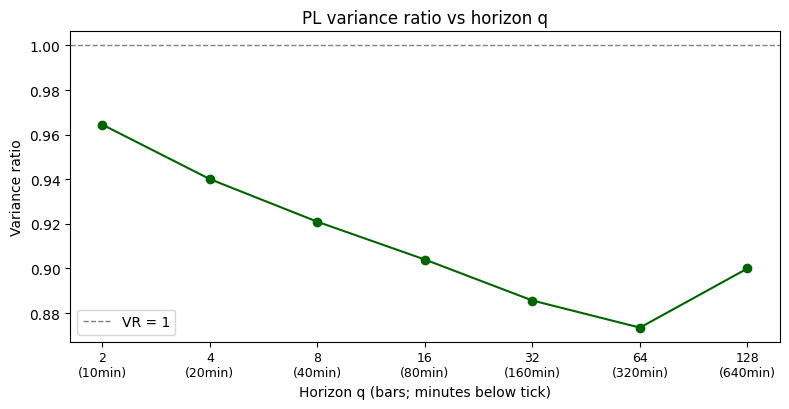

In [298]:
# Basic VR plot
fig3, ax3 = plt.subplots(figsize=(8, 4.2))

ax3.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="VR = 1")
ax3.set_xscale("log", base=2)
ax3.plot(vr_summary["q"], vr_summary["VR"], marker="o", color="darkgreen")

q_ticks = np.asarray(vr_summary["q"], dtype=float)
vr_tick_labels = [bar_minutes(int(q), MINUTES_PER_BAR) for q in vr_summary["q"]]

ax3.xaxis.set_major_locator(mticker.FixedLocator(q_ticks))
ax3.xaxis.set_major_formatter(mticker.FixedFormatter(vr_tick_labels))
ax3.xaxis.set_minor_locator(mticker.NullLocator())

for lab in ax3.get_xticklabels():
    lab.set_fontsize(9)

ax3.set_title(f"{MARKET_NAME} variance ratio vs horizon q")
ax3.set_xlabel("Horizon q (bars; minutes below tick)")
ax3.set_ylabel("Variance ratio")
ax3.legend(loc="best")

fig3.tight_layout()

vr_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_vr.png")
fig3.savefig(vr_path, dpi=120, bbox_inches="tight")

####Result

After removing non-5-minute gap returns, PL VR values are below 1 for every tested horizon.

The 5-minute base-scale results are:

- q = 2, 10min: VR ≈ 0.964
- q = 4, 20min: VR ≈ 0.940
- q = 8, 40min: VR ≈ 0.921
- q = 16, 80min: VR ≈ 0.904
- q = 32, 160min: VR ≈ 0.886
- q = 64, 320min: VR ≈ 0.873
- q = 128, 640min: VR ≈ 0.900

The VR values go down from q = 2 to q = 64. This means the negative serial dependence becomes stronger from 10 minutes to about 320 minutes.

At q = 128, VR goes up a little, but it is still below 1.

So the VR result does not support pure Random Walk for PL. It supports mean-reversion in the intraday return sample.

In [299]:
# VR with CI plot
def plot_vr_ci(vr_summary, output_dir):
    x = np.arange(len(vr_summary))
    y = vr_summary['VR'].to_numpy(dtype=float)
    ci_low = vr_summary['ci_lower'].to_numpy(dtype=float)
    ci_up = vr_summary['ci_upper'].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(x, y, marker='o', color='darkgreen', linewidth=1.8, label='VR')
    ax.fill_between(x, ci_low, ci_up, color='darkgreen', alpha=0.18, label='95% robust CI')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='VR = 1 (Random Walk)')
    labels = [f'{int(q)}\n({int(m)}min)' for q, m in zip(vr_summary['q'], vr_summary['horizon_minutes'])]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Variance Ratio, VR(q)')
    ax.set_xlabel('Time Horizon q (bars and minutes)')
    ax.set_title('Variance Ratio vs. Horizon (q) with 95% Robust Confidence Intervals')
    ax.legend(loc='best', fontsize=8)
    fig.tight_layout()
    out_path = os.path.join(output_dir, 'PL_vr_with_robust_ci.png')
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    return out_path

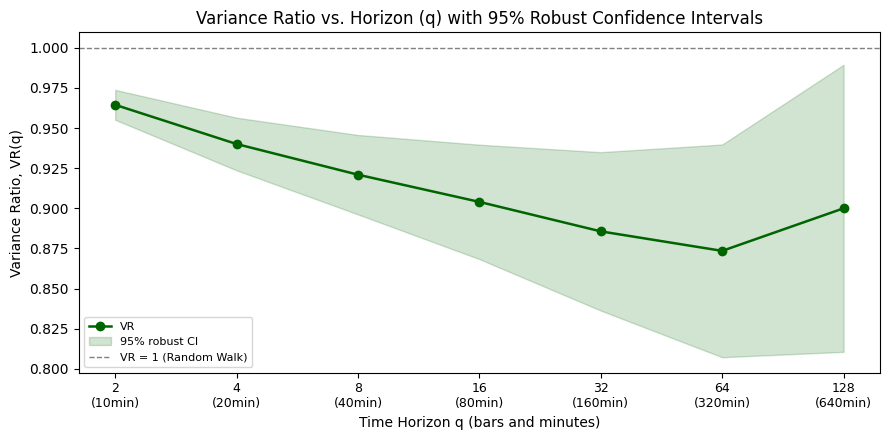

In [300]:
vr_ci_plot_path = plot_vr_ci(vr_summary, OUTPUT_DIR)


## Result

The VR + 95% robust CI graph is the main Random Walk test result.

Green line: VR estimate.

Dashed line: VR = 1 (Random Walk benchmark)

Shaded area: 95% robust confidence interval

For PL, the VR line stays below 1 across all tested q values, meaing that the result points to negative serial dependence and mean-reversion.

The strongest difference from Random Walk is around q = 64, which is about 320 minutes.

At q = 128, the effect becomes a little weaker, but VR is still below 1.

## 8. Multi-scale VR

The multi-scale VR heatmap helps to check whether the PL mean-reversion result also appears at other base frequencies.

Each cell reports VR(q) - 1.

- Negative: mean-reversion
- Positive: momentum
- Close to zero: closer to Random Walk
- Stars: strong statistical evidence

In [301]:
# Aggregate intraday bars into larger timeframes (e.g., converting 5-min bars into 15-min or 1H bars)
def agg_bars(df_prices, bars_per_bucket):
    if bars_per_bucket <= 1:
        return df_prices[['datetime', 'Close']].copy()

    tmp = df_prices[['datetime', 'Close']].copy().sort_values('datetime').reset_index(drop=True)

    # Isolate the date to prevent cross-day buckets
    # (we don't want an overnight gap grouped inside a single intraday bucket)
    tmp['session_date'] = tmp['datetime'].dt.date
    tmp['bar_no'] = tmp.groupby('session_date').cumcount()

    # Group sequential bars into chunks of size 'bars_per_bucket'
    tmp['bucket'] = tmp['bar_no'] // bars_per_bucket

    # Ensure we only keep full, complete buckets to avoid skewed returns from partial periods at the end of a day
    tmp['bucket_size'] = tmp.groupby(['session_date', 'bucket'])['Close'].transform('size')
    tmp = tmp[tmp['bucket_size'] == bars_per_bucket].copy()

    # For each bucket, the 'close' is the final recorded price (last), and the time is the end of the bucket (max)
    agg = tmp.groupby(['session_date', 'bucket'], as_index=False).agg(datetime=('datetime', 'max'), Close=('Close', 'last')).sort_values('datetime').reset_index(drop=True)

    return agg[['datetime', 'Close']]

In [302]:
# Multi-scale Variance Ratio (VR) Test
# Tests the random walk hypothesis across multiple aggregated timeframes (from 5 minutes up to 4 hours)
def multiscale_vr(df_prices):
    # Define the scales to test: (Label, bars multiplier, list of 'q' step horizons)
    scales = [('5min', 1, [2, 4, 8, 16, 32]), ('15min', 3, [2, 4, 8, 16, 32]), ('30min', 6, [2, 4, 8, 16, 32]), ('1H', 12, [2, 4, 8, 16, 32]), ('2H', 24, [2, 4, 8, 16]), ('3H', 36, [2, 4, 8]), ('4H', 48, [2, 4])]
    detail_rows = []

    # Iterate through each timeframe, aggregate the underlying data, and run the VR test
    for label, bars_per_bucket, q_list in scales:
        agg_prices = agg_bars(df_prices, bars_per_bucket)
        ret_df = calc_returns(agg_prices, minutes_per_bar=MINUTES_PER_BAR * bars_per_bucket)
        ret = ret_df['log_ret']

        # Test multiple forward-looking horizons 'q' for this specific timeframe
        for q in q_list:
            res = vr_test(ret, q)
            if np.isnan(res['VR']):
                continue
            p = float(res['robust_p_value'])

            # We store VR_minus_1 to center the random walk baseline at 0.0 (makes it intuitive for heatmaps)
            detail_rows.append({'base_frequency': label, 'bars_per_bucket': int(bars_per_bucket), 'q': int(q), 'horizon_minutes': int(q * bars_per_bucket * MINUTES_PER_BAR), 'VR': float(res['VR']), 'VR_minus_1': float(res['VR'] - 1.0), 'robust_p_value': p, 'significance': vr_sig(p)})

    detail = pd.DataFrame(detail_rows)
    if detail.empty:
        return (detail, pd.DataFrame(), pd.DataFrame())

    # Pivot the detailed results into 2D matrices (Rows=Frequency, Cols=Horizons) for easy visualization
    summary = detail.pivot(index='base_frequency', columns='q', values='VR_minus_1')
    stars = detail.pivot(index='base_frequency', columns='q', values='significance')

    # Enforce chronological ordering on the frequency labels and q horizons so the matrix isn't shuffled
    freq_order = [label for label, _, _ in scales]
    q_order = sorted(detail['q'].unique())
    summary = summary.reindex(index=freq_order, columns=q_order)
    stars = stars.reindex(index=freq_order, columns=q_order)

    return (detail, summary, stars)

In [303]:
# Multi-scale VR tables
detail, ms_summary, ms_stars = multiscale_vr(df[["datetime", "Close"]])

ms_detail_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_multiscale_vr_detail.csv")
ms_pivot_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_multiscale_vr_pivot.csv")
ms_annotated_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_multiscale_vr_heatmap_table.csv")

if detail.empty:
    pd.DataFrame().to_csv(ms_detail_path, index=False)
    pd.DataFrame().to_csv(ms_pivot_path)
    pd.DataFrame().to_csv(ms_annotated_path)
else:
    detail_export = detail.copy()
    detail_export["cell"] = (
        detail_export["VR_minus_1"].round(4).astype(str)
        + detail_export["significance"].fillna("")
    )
    detail_export.to_csv(ms_detail_path, index=False)

    ms_summary.to_csv(ms_pivot_path)

    ms_annotated = pd.DataFrame("", index=ms_summary.index, columns=ms_summary.columns)

    for idx in ms_summary.index:
        for col in ms_summary.columns:
            val = ms_summary.loc[idx, col]
            star = ms_stars.loc[idx, col] if idx in ms_stars.index and col in ms_stars.columns else ""

            if pd.isna(val):
                ms_annotated.loc[idx, col] = ""
            else:
                ms_annotated.loc[idx, col] = f"{val:.4f}{star}"

    ms_annotated.to_csv(ms_annotated_path)

display(ms_annotated)

q,2,4,8,16,32
base_frequency,,,,,
5min,-0.0335**,-0.0578**,-0.0770**,-0.0917**,-0.1077**
15min,-0.0184**,-0.0358**,-0.0449**,-0.0487*,-0.0339
30min,-0.0071,-0.0198,-0.0297,-0.0099,0.0000
1H,-0.0097,-0.0229,-0.0083,-0.0217,-0.0580
2H,0.0352*,0.0568,0.0543,0.0916,
3H,,,,,
4H,,,,,


In [304]:
# Multi-scale heatmap
def plot_heatmap(summary, stars, output_dir):
    if summary.empty:
        return ''
    plot_df = summary.copy()
    star_df = stars.reindex(index=plot_df.index, columns=plot_df.columns).fillna('')
    vals = plot_df.to_numpy(dtype=float)
    vmax = float(np.nanmax(np.abs(vals))) if np.isfinite(vals).any() else 1.0
    vmax = max(vmax, 1e-06)
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(vals, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label='VR(q) - 1 (0 = Random Walk)')
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels([str(int(c)) for c in plot_df.columns])
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index.tolist())
    for i in range(plot_df.shape[0]):
        for j in range(plot_df.shape[1]):
            v = vals[i, j]
            if np.isnan(v):
                txt = ''
            else:
                txt = f'{v:.3f}{star_df.iloc[i, j]}'
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=8)
    ax.set_title('Multi-Scale Variance Ratio Heatmap: VR(q) - 1')
    ax.set_xlabel('Forward Time Horizon (q periods)')
    ax.set_ylabel('Base Bar Aggregation Frequency')
    fig.tight_layout()
    out_path = os.path.join(output_dir, 'PL_multiscale_vr_heatmap.png')
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    return out_path

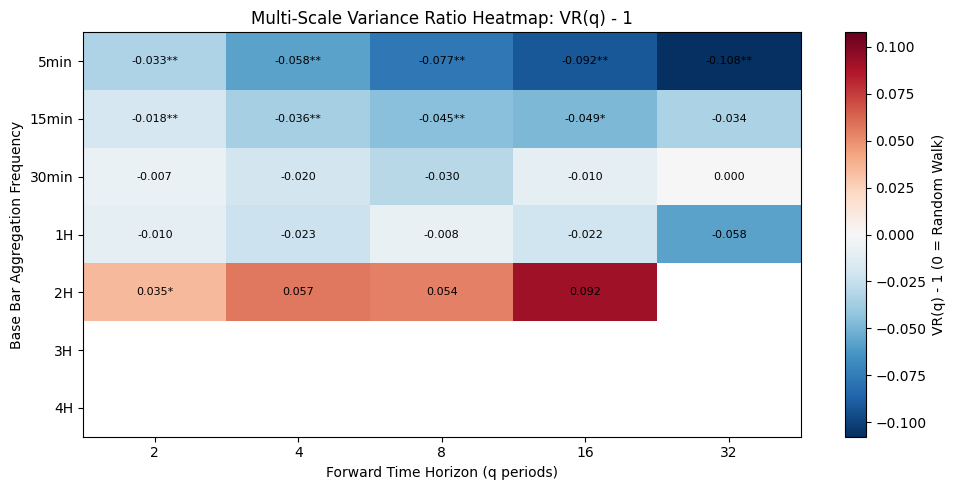

In [305]:
ms_heatmap_path = plot_heatmap(ms_summary, ms_stars, OUTPUT_DIR)

#### Result
5min: all negative and strong

15min: mostly negative, especially from q = 2 to q = 16

30min and 1H: mostly negative, but weaker and not always significant

2H: some cells become positive.

3H and 4H: blank because there are not enough valid intraday buckets under this aggregation rule. This does not mean the effect is zero.

PL is not mean-reverting at every single time scale. To provide a better conclusion, we would say that PL has strong short-to-intermediate intraday mean-reversion, but longer aggregated horizons become less stable.

## 9. Push-Response

The course-taught empirical test: binned mean response vs push, sign-based summary, and correlation of sign(push) with response across horizons.
For each horizon h bars:

- push_t(h) = r_{t-h+1} + r_{t-h+2} + ... + r_t  (past cumulative log return)
- resp_t(h) = r_{t+1} + r_{t+2} + ... + r_{t+h}   (next-h cumulative log return)

We sort push_t into quantile bins and report mean resp per bin, then a sign-based summary, and the correlation between sign(push) and response across horizons.


In [306]:
# Push-response pairs
def pr_pairs(log_returns, h):
    r = log_returns.dropna().astype(float).to_numpy()
    n = len(r)
    if h < 1 or n < 2 * h + 1:
        return pd.DataFrame(columns=['t_index', 'push', 'response'])
    cs = np.concatenate(([0.0], np.cumsum(r)))
    t_vals = np.arange(h, n - h + 1, h)
    push_vals = cs[t_vals] - cs[t_vals - h]
    resp_vals = cs[t_vals + h] - cs[t_vals]
    return pd.DataFrame({'t_index': t_vals, 'push': push_vals, 'response': resp_vals})

In [307]:
# Empirical push-response bins
# Categorizes historical 'pushes' (momentum) into distinct bins to analyze non-linear or asymmetric market responses.
def pr_bins(pairs_df, n_bins_preferred=9, min_per_bin=5):
    empty = pd.DataFrame(columns=['bin_rank', 'mean_push', 'mean_response', 'count', 'se_response', 'n_bins_effective', 'binning'])
    if pairs_df.empty or len(pairs_df) < 2:
        return empty

    push = pairs_df['push'].to_numpy(dtype=float)
    resp = pairs_df['response'].to_numpy(dtype=float)
    n = len(push)
    candidates: List[int] = []
    for x in (n_bins_preferred, 11, 7, 10, 12, 8, 6, 5):
        if x not in candidates:
            candidates.append(x)

    best_lab = None
    best_min = -1
    best_binning = 'quantile'

    # First attempt: Try to use quantile-based binning (pd.qcut) so that each bin
    # has approximately the same number of observations (statistically robust).
    for nb in candidates:
        if nb < 2 or n < nb:
            continue
        try:
            lab = pd.qcut(push, nb, labels=False, duplicates='drop')
            lab = np.asarray(lab, dtype=int)
            vc = pd.Series(lab).value_counts()
            mn = int(vc.min()) if len(vc) else 0
            if mn >= min_per_bin:
                best_lab = lab
                best_min = mn
                best_binning = 'quantile'
                break
            if mn > best_min:
                best_lab, best_min = (lab, mn)
                best_binning = 'quantile'
        except (ValueError, TypeError):
            continue

    # Fallback attempt: If quantile binning fails (e.g., too many identical zero returns/ties),
    # fall back to equal-width binning (pd.cut) slicing the absolute range of pushes.
    if best_lab is None:
        lo, hi = (float(np.min(push)), float(np.max(push)))
        if hi <= lo:
            best_lab = np.zeros(n, dtype=int)
            best_binning = 'equal_width'
        else:
            for nb in candidates:
                if nb < 2:
                    continue
                try:
                    lab = pd.cut(push, bins=nb, labels=False, duplicates='drop')
                    lab = np.asarray(lab, dtype=float)
                    if np.any(np.isnan(lab)):
                        continue
                    lab = lab.astype(int)
                    vc = pd.Series(lab).value_counts()
                    mn = int(vc.min()) if len(vc) else 0
                    if mn >= min_per_bin:
                        best_lab = lab
                        best_min = mn
                        best_binning = 'equal_width'
                        break
                    if mn > best_min:
                        best_lab, best_min = (lab, mn)
                        best_binning = 'equal_width'
                except (ValueError, TypeError):
                    continue

    if best_lab is None:
        return empty

    # Aggregate the responses within each selected bin to find conditional mean and standard error
    lab = np.asarray(best_lab, dtype=int)
    uniq = np.unique(lab[~np.isnan(lab)])
    rows: List[dict] = []
    for b in uniq:
        m = lab == b
        if not np.any(m):
            continue
        pbin, rbin = (push[m], resp[m])
        cnt = int(np.sum(m))
        se = float(np.std(rbin, ddof=1) / math.sqrt(cnt)) if cnt > 1 else float('nan')
        rows.append({'bin_rank': 0, 'mean_push': float(np.mean(pbin)), 'mean_response': float(np.mean(rbin)), 'count': cnt, 'se_response': se, 'n_bins_effective': len(uniq), 'binning': best_binning})

    out = pd.DataFrame(rows)
    if out.empty:
        return empty
    out = out.sort_values('mean_push').reset_index(drop=True)
    out['bin_rank'] = np.arange(1, len(out) + 1)
    out['n_bins_effective'] = len(out)
    return out

In [308]:
# Empirical push-response table
def emp_pr(log_returns, h_list, minutes_per_bar, n_bins_preferred):
    blocks: List[pd.DataFrame] = []
    for h in h_list:
        pairs = pr_pairs(log_returns, h)
        bdf = pr_bins(pairs, n_bins_preferred=n_bins_preferred)
        if bdf.empty:
            continue
        hm = h * minutes_per_bar
        bdf = bdf.copy()
        bdf.insert(0, 'h_bars', h)
        bdf.insert(1, 'h_minutes', hm)
        bdf.insert(2, 'h_hours', hm / 60.0)
        bdf.insert(3, 'h_label', q_label(hm))
        bdf.insert(4, 'n_bins_requested', n_bins_preferred)
        blocks.append(bdf)
    if not blocks:
        return pd.DataFrame()
    return pd.concat(blocks, ignore_index=True)

In [309]:
# Calculate conditional summary statistics for the push-response relationship at a specific horizon 'h'
def pr_stats(log_returns, h):
    df = pr_pairs(log_returns, h)
    if df.empty:
        return (float('nan'), float('nan'), float('nan'), float('nan'), float('nan'), 0, 0)

    # Split the data into events where the initial 'push' (recent momentum) was positive vs negative
    pos = df['push'] > 0
    neg = df['push'] < 0
    resp_pos = df.loc[pos, 'response'].to_numpy(dtype=float)
    resp_neg = df.loc[neg, 'response'].to_numpy(dtype=float)

    # Calculate the conditional mean responses (average return after it goes up, vs after it goes down)
    avg_pos = float(np.mean(resp_pos)) if len(resp_pos) else float('nan')
    avg_neg = float(np.mean(resp_neg)) if len(resp_neg) else float('nan')

    # Unconditional mean (the baseline average return over length 'h' regardless of preceding push)
    unconditional = float(df['response'].mean())

    # Check the linear correlation between the binary sign of the push (+1 or -1) and the actual subsequent response
    push_sign = np.sign(df['push'])
    corr_sign = float(pd.Series(push_sign, index=df.index).corr(df['response']))

    # Perform Welch's t-test to check if the average responses to positive vs negative pushes are statistically different
    wt = welch_t(resp_pos, resp_neg)

    return (avg_pos, avg_neg, unconditional, corr_sign, wt, int(pos.sum()), int(neg.sum()))

In [310]:
# Push-response interpretation
def pr_note(response_difference, welch_t):
    if np.isnan(response_difference) or np.isnan(welch_t):
        return 'weak / unclear'
    if response_difference > 0 and welch_t >= 2:
        return 'continuation flavor'
    if response_difference < 0 and welch_t <= -2:
        return 'reversal flavor'
    return 'weak / unclear'

In [311]:
# Push-response table
def pr_table(log_returns, h_list, minutes_per_bar):
    rows = []
    for h in h_list:
        avg_pos, avg_neg, uncond, corr_s, welch_t, n_pos, n_neg = pr_stats(log_returns, h)
        response_difference = avg_pos - avg_neg if not (np.isnan(avg_pos) or np.isnan(avg_neg)) else float('nan')
        h_bars = h
        h_minutes = h_bars * minutes_per_bar
        h_hours = h_minutes / 60.0
        rows.append({'h': h, 'h_bars': h_bars, 'h_minutes': h_minutes, 'h_hours': h_hours, 'h_label': q_label(h_minutes), 'avg_response_after_pos_push': avg_pos, 'avg_response_after_neg_push': avg_neg, 'unconditional_mean_future_response': uncond, 'response_difference': response_difference, 'corr_push_sign_response': corr_s, 'welch_t_future_response_pos_minus_neg': welch_t, 'n_positive_pushes': n_pos, 'n_negative_pushes': n_neg, 'interpretation': pr_note(response_difference, welch_t)})
    return pd.DataFrame(rows)

In [312]:
def format_pr(pr_df):
    cols = ['h_bars', 'h_minutes', 'h_hours', 'h_label', 'avg_response_after_pos_push', 'avg_response_after_neg_push', 'unconditional_mean_future_response', 'response_difference', 'corr_push_sign_response', 'welch_t_future_response_pos_minus_neg', 'interpretation', 'n_positive_pushes', 'n_negative_pushes']
    out = pr_df[cols].copy()
    out['h_hours'] = out['h_hours'].round(2)
    for c in ['avg_response_after_pos_push', 'avg_response_after_neg_push', 'unconditional_mean_future_response', 'response_difference', 'corr_push_sign_response']:
        out[c] = out[c].round(6)
    out['welch_t_future_response_pos_minus_neg'] = out['welch_t_future_response_pos_minus_neg'].round(3)
    return out

def format_emp(emp_df):
    if emp_df.empty:
        return emp_df
    out = emp_df.copy()
    if 'h_hours' in out.columns:
        out['h_hours'] = out['h_hours'].round(2)
    for c in ('mean_push', 'mean_response', 'se_response'):
        if c in out.columns:
            out[c] = out[c].round(6)
    return out

In [313]:
pr_emp = emp_pr(
    df["log_ret"],
    PUSH_RESPONSE_H_VALUES,
    MINUTES_PER_BAR,
    PUSH_RESPONSE_EMPIRICAL_N_BINS,
)

pr_emp_disp = format_emp(pr_emp)
pr_emp_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_empirical_push_response_results.csv")
pr_emp_disp.to_csv(pr_emp_path, index=False)

In [314]:
pr_df = pr_table(df["log_ret"], PUSH_RESPONSE_H_VALUES, MINUTES_PER_BAR)

pr_final = format_pr(pr_df)
pr_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_push_response_results.csv")
pr_final.to_csv(pr_path, index=False)

In [315]:
display(pr_emp_disp.head(6))
display(pr_final)

,h_bars,h_minutes,h_hours,h_label,n_bins_requested,bin_rank,mean_push,mean_response,count,se_response,n_bins_effective,binning
0,2,10,0.17,10 min (0.17 h),9,1,-0.003727,0.000095,14865,0.000026,9,quantile
1,2,10,0.17,10 min (0.17 h),9,2,-0.001543,0.000027,14864,0.000017,9,quantile
2,2,10,0.17,10 min (0.17 h),9,3,-0.000836,0.000025,14865,0.000015,9,quantile
3,2,10,0.17,10 min (0.17 h),9,4,-0.000364,0.000003,14864,0.000014,9,quantile
4,2,10,0.17,10 min (0.17 h),9,5,0.000011,0.000005,14865,0.000014,9,quantile
5,2,10,0.17,10 min (0.17 h),9,6,0.000389,-0.000009,14864,0.000014,9,quantile


,h_bars,h_minutes,h_hours,h_label,avg_response_after_pos_push,avg_response_after_neg_push,unconditional_mean_future_response,response_difference,corr_push_sign_response,welch_t_future_response_pos_minus_neg,interpretation,n_positive_pushes,n_negative_pushes
0,2,10,0.17,10 min (0.17 h),-0.000038,0.000034,-0.000001,-0.000072,-0.016467,-5.983,reversal flavor,64895,63938
1,4,20,0.33,20 min (0.33 h),-0.000034,0.000027,-0.000002,-0.000061,-0.010068,-2.593,reversal flavor,32975,32341
2,8,40,0.67,40 min (0.67 h),-0.000013,0.000016,-0.000004,-0.000030,-0.003481,-0.638,weak / unclear,16645,16296
3,16,80,1.33,80 min,-0.000074,0.000045,-0.000009,-0.000119,-0.010104,-1.303,weak / unclear,8351,8201
4,32,160,2.67,160 min,0.000067,-0.000113,-0.000017,0.000180,0.010929,0.999,weak / unclear,4172,4151


Push-Response t-test table

In [316]:
try:
    from scipy import stats
except ImportError:
    stats = None

In [317]:
# Welch's t-test with p-value calculation
# Standard t-tests assume equal variance between the two groups.
# Welch's t-test is used here because the variance of returns following a positive push
# might differ from the variance of returns following a negative push (heteroskedasticity).
def welch_p(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Filter out NaNs to ensure accurate moment calculations
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    if len(x) < 2 or len(y) < 2:
        return float("nan"), float("nan"), float("nan")

    nx = len(x)
    ny = len(y)

    mx = np.mean(x)
    my = np.mean(y)

    # Unbiased sample variances (ddof=1)
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    # Calculate the squared standard error of the difference between the two means
    se2 = vx / nx + vy / ny

    if se2 <= 0 or np.isnan(se2):
        return float("nan"), float("nan"), float("nan")

    # T-statistic measures how many standard errors the observed difference is away from 0
    t_stat = (mx - my) / np.sqrt(se2)

    # Welch-Satterthwaite equation to approximate the effective degrees of freedom
    df_num = se2 ** 2
    df_den = ((vx / nx) ** 2) / (nx - 1) + ((vy / ny) ** 2) / (ny - 1)
    df_welch = df_num / df_den if df_den > 0 else float("nan")

    # Calculate the two-tailed p-value using scipy if available, otherwise fallback to normal approximation
    if stats is not None and np.isfinite(df_welch):
        p_value = 2 * stats.t.sf(abs(t_stat), df_welch)
    else:
        p_value = z_pvalue(t_stat)

    return float(t_stat), float(p_value), float(df_welch)

In [318]:
# Significance and interpretation labels
def pr_sig(p):
    if np.isnan(p):
        return ""
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def pr_dir(diff, p):
    if np.isnan(diff) or np.isnan(p):
        return "unclear"
    if p < 0.05 and diff < 0:
        return "significant reversal"
    if p < 0.05 and diff > 0:
        return "significant continuation"
    if diff < 0:
        return "weak reversal"
    if diff > 0:
        return "weak continuation"
    return "unclear"

In [319]:
# Push-Response t-test table
pr_test_rows = []

for h in PUSH_RESPONSE_H_VALUES:
    pairs = pr_pairs(df["log_ret"], h)

    resp_pos = pairs.loc[pairs["push"] > 0, "response"].to_numpy(dtype=float)
    resp_neg = pairs.loc[pairs["push"] < 0, "response"].to_numpy(dtype=float)

    mean_pos = np.mean(resp_pos) if len(resp_pos) else float("nan")
    mean_neg = np.mean(resp_neg) if len(resp_neg) else float("nan")
    diff = mean_pos - mean_neg if len(resp_pos) and len(resp_neg) else float("nan")

    t_stat, p_value, df_welch = welch_p(resp_pos, resp_neg)

    pr_test_rows.append(
        {
            "h_bars": h,
            "h_minutes": h * MINUTES_PER_BAR,
            "mean_response_after_positive_push": mean_pos,
            "mean_response_after_negative_push": mean_neg,
            "difference_pos_minus_neg": diff,
            "welch_t_stat": t_stat,
            "welch_df": df_welch,
            "p_value": p_value,
            "significance": pr_sig(p_value),
            "n_positive_pushes": len(resp_pos),
            "n_negative_pushes": len(resp_neg),
            "interpretation": pr_dir(diff, p_value),
        }
    )

pr_test_table = pd.DataFrame(pr_test_rows)

In [320]:
# Push-Response t-test table format
pr_test_display = pr_test_table.copy()

for col in [
    "mean_response_after_positive_push",
    "mean_response_after_negative_push",
    "difference_pos_minus_neg",
]:
    pr_test_display[col] = pr_test_display[col].round(8)

pr_test_display["welch_t_stat"] = pr_test_display["welch_t_stat"].round(3)
pr_test_display["welch_df"] = pr_test_display["welch_df"].round(1)
pr_test_display["p_value"] = pr_test_display["p_value"].round(4)

pr_test_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_push_response_ttest_table.csv")
pr_test_table.to_csv(pr_test_path, index=False)

display(pr_test_display)

,h_bars,h_minutes,mean_response_after_positive_push,mean_response_after_negative_push,difference_pos_minus_neg,welch_t_stat,welch_df,p_value,significance,n_positive_pushes,n_negative_pushes,interpretation
0,2,10,-0.000038,0.000034,-0.000072,-5.983,128438.5,0.0000,**,64895,63938,significant reversal
1,4,20,-0.000034,0.000027,-0.000061,-2.593,65184.8,0.0095,**,32975,32341,significant reversal
2,8,40,-0.000013,0.000016,-0.000030,-0.638,32898.6,0.5236,,16645,16296,weak reversal
3,16,80,-0.000074,0.000045,-0.000119,-1.303,16543.2,0.1925,,8351,8201,weak reversal
4,32,160,0.000067,-0.000113,0.000180,0.999,8318.9,0.3178,,4172,4151,weak continuation


Push-Response plots

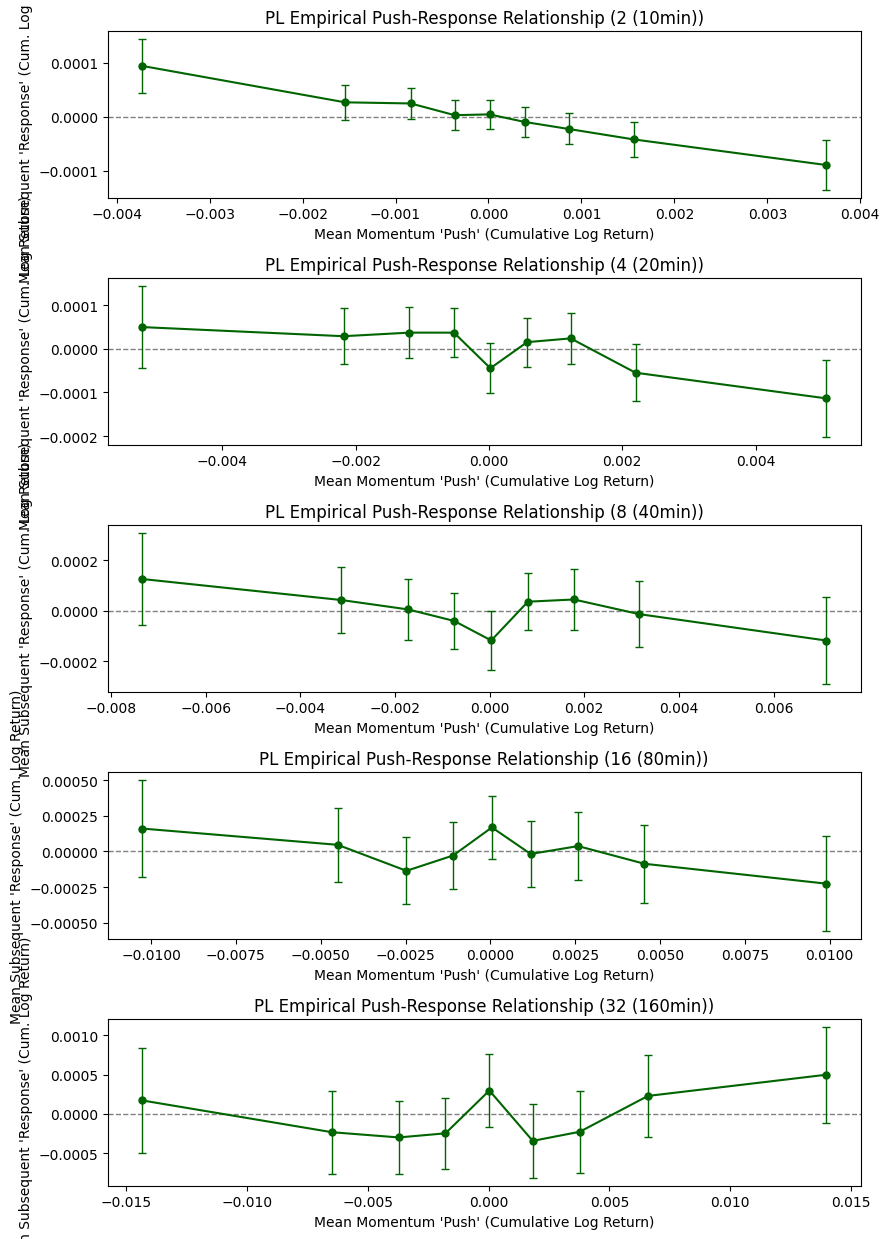

In [321]:
# Empirical push-response plot
n_h = len(PUSH_RESPONSE_H_VALUES)
fig_pr, axes_pr = plt.subplots(nrows=n_h, ncols=1, figsize=(9, 2.5 * n_h), sharex=False)

if n_h == 1:
    axes_pr = np.asarray([axes_pr])

for ax, h in zip(axes_pr, PUSH_RESPONSE_H_VALUES):
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)

    sub = pr_emp[pr_emp["h_bars"] == h] if not pr_emp.empty else pd.DataFrame()

    if sub.empty:
        ax.text(0.5, 0.5, "no binned data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{MARKET_NAME} h={h} bars")
        continue

    xb = sub["mean_push"].to_numpy(dtype=float)
    yb = sub["mean_response"].to_numpy(dtype=float)
    se = sub["se_response"].to_numpy(dtype=float)
    yerr = np.where(np.isfinite(se) & (se > 0), 1.96 * se, np.nan)

    ax.errorbar(xb, yb, yerr=yerr, fmt="o-", color="darkgreen", capsize=3, markersize=5, elinewidth=1)
    ax.set_xlabel("Mean Momentum 'Push' (Cumulative Log Return)")
    ax.set_ylabel("Mean Subsequent 'Response' (Cum. Log Return)")

    ht = bar_minutes(int(h), MINUTES_PER_BAR).replace("\n", " ")
    ax.set_title(f"{MARKET_NAME} Empirical Push-Response Relationship ({ht})")

fig_pr.tight_layout()

pr_emp_fig_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_pushresponse_empirical.png")
fig_pr.savefig(pr_emp_fig_path, dpi=120, bbox_inches="tight")

#### Result

h = 2(10 minutes): clear slopes downward
*   Bigger negative pushes are followed by more positive average responses.
*   A very clear mean-reversion pattern

h = 4 & h = 8: downward, but noisier in the middle

h = 16: not smooth, but still looks more like weak reversal

h = 32: mixed curve with not completely clean downward curve and some positive push areas


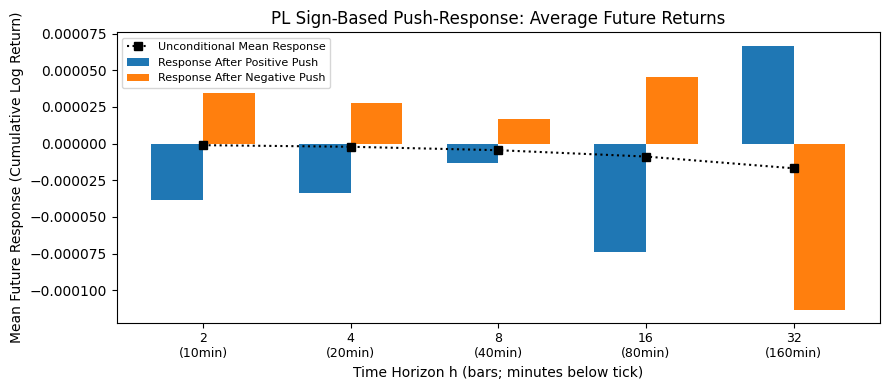

In [322]:
# Sign-based Push-Response summary plot
x = np.arange(len(pr_df))
w = 0.35

fig4, ax4 = plt.subplots(figsize=(9, 4))

ax4.bar(x - w / 2, pr_df["avg_response_after_pos_push"], width=w, label="Response After Positive Push")
ax4.bar(x + w / 2, pr_df["avg_response_after_neg_push"], width=w, label="Response After Negative Push")

ax4.plot(
    x,
    pr_df["unconditional_mean_future_response"],
    color="black",
    linestyle=":",
    marker="s",
    label="Unconditional Mean Response",
)

ax4.set_xticks(x)
ax4.set_xticklabels([bar_minutes(int(h), MINUTES_PER_BAR) for h in pr_df["h_bars"]], fontsize=9)
ax4.set_xlabel("Time Horizon h (bars; minutes below tick)")
ax4.set_ylabel("Mean Future Response (Cumulative Log Return)")
ax4.set_title(f"{MARKET_NAME} Sign-Based Push-Response: Average Future Returns")
ax4.legend(fontsize=8)

fig4.tight_layout()

pr_fig_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_pushresponse.png")
fig4.savefig(pr_fig_path, dpi=120, bbox_inches="tight")

### Simpler summary as a sign based

For h = 2, 4, 8, and 16, the average response after positive push is negative. The average response after negative push is positive.


*   mean-reversion.

At h = 32, the result changes. Positive pushes are followed by positive responses, and negative pushes are followed by negative responses.

*   momentum-like


So the sign-based result is similar to the binned curves. PL has reversal at shorter horizons, but the pattern becomes mixed at longer horizon.

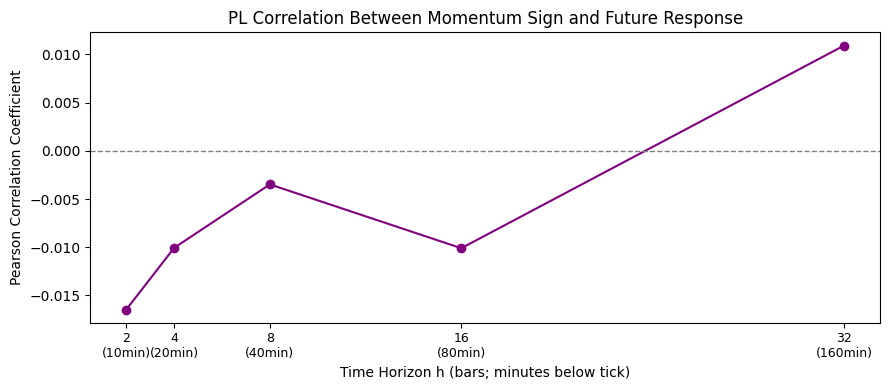

In [323]:
# Correlation plot
fig5, ax5 = plt.subplots(figsize=(9, 4))

ax5.plot(pr_df["h"], pr_df["corr_push_sign_response"], marker="o", color="purple")
ax5.axhline(0.0, color="gray", linestyle="--", linewidth=1)

ax5.set_xticks(list(pr_df["h"]))
ax5.set_xticklabels([bar_minutes(int(h), MINUTES_PER_BAR) for h in pr_df["h_bars"]], fontsize=9)
ax5.set_title(f"{MARKET_NAME} Correlation Between Momentum Sign and Future Response")
ax5.set_xlabel("Time Horizon h (bars; minutes below tick)")
ax5.set_ylabel("Pearson Correlation Coefficient")

fig5.tight_layout()

corr_fig_path = os.path.join(OUTPUT_DIR, f"{FILE_SLUG}_corr.png")
fig5.savefig(corr_fig_path, dpi=120, bbox_inches="tight")

#### Correlation Result

h = 2 to h = 16: Negative correlation between sign(push) and future response


*   supports short-horizon mean-reversion

h = 32: Become positive



*   supports the idea reversal effect becomes weaker and moves toward a more momentum-like pattern

## 10. Conclusion

*  Inefficiency type

1. VR is below 1 across the main tested horizons
2. Push-response also supports reversal at short horizons
3. At longer horizons, the result becomes more mixed

So PL is not a clear trend-following market. It is more reversal-driven, especially at short-to-intermediate intraday horizons.


Overall, PL does not behave like a pure Random Walk in the intraday return sample.

1. VR gives strong evidence of mean-reversion.
2. Push-response also shows reversal at shorter horizons.
3. The pattern becomes weaker and mixed at longer horizons.

Main conclusion: PL has short-to-intermediate intraday mean-reversion.


## 11. Save figures

In [324]:
def safe_name(text):
    text = str(text).strip().lower()
    text = re.sub('[^a-z0-9]+', '_', text)
    text = re.sub('_+', '_', text).strip('_')
    return text or 'figure'

In [325]:
def save_figs(output_dir=FIGURE_DIR, prefix=FILE_SLUG, dpi=160):
    os.makedirs(output_dir, exist_ok=True)
    saved_paths = []
    for i, fig_num in enumerate(plt.get_fignums(), start=1):
        fig = plt.figure(fig_num)
        title = ''
        for ax in fig.axes:
            if ax.get_title():
                title = ax.get_title()
                break
        title_slug = safe_name(title)
        filename = f'{prefix}_fig{i:02d}_{title_slug}.png'
        path = os.path.join(output_dir, filename)
        fig.savefig(path, dpi=dpi, bbox_inches='tight')
        saved_paths.append(path)
    return saved_paths

In [326]:
saved_paths = save_figs()
